# Diffusion Toy Example

## Imports, Device Selection, Seed

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from backbones.mlp import MLP
from diffusion.edm import Precond, EDM2Loss
from samplers.edm_sampler import edm_sampler

In [2]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [3]:
torch.manual_seed(50192834)

## Toy Data (Circles)

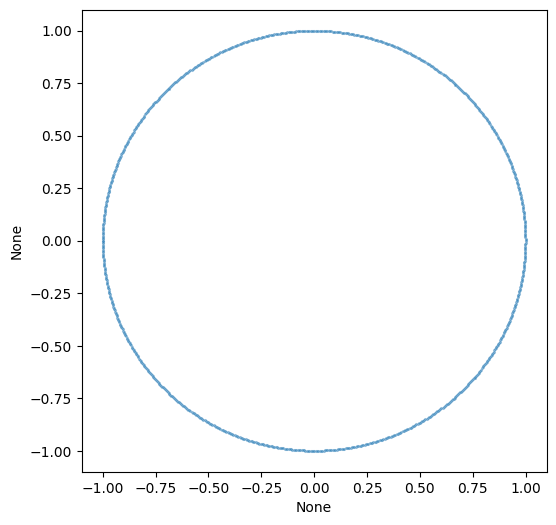

In [4]:
n_points = 1<<10
radii = torch.ones(n_points)
thetas = torch.linspace(-torch.pi, torch.pi, n_points)
x = radii * torch.cos(thetas)
y = radii * torch.sin(thetas)
data = torch.stack([x, y], dim=-1)

# Visualize the data distribution.
plt.figure(figsize=(6, 6))
sns.scatterplot(x=data[:, 0], y=data[:, 1], s=5, alpha=0.5)
plt.show()

In [5]:
# Preprocess to variance 0.5, which is the expected standard deviation of the training data.
dataset = data / torch.std(data) * 0.5

# split into train and test sets
dataset = dataset[torch.randperm(dataset.shape[0])]
train_data = dataset[:768]
test_data = dataset[768:]

print(train_data.shape, test_data.shape)

torch.Size([768, 2]) torch.Size([256, 2])


## Model, Loss Instantiation

In [6]:
# Model hyperparameters.
in_dim = 2
hidden_dim = 128
num_layers = 3
sigma_data = 0.5

# Loss hyperparameters.
P_mean = -2.3
P_std = 1.1

# Initialize the model and the loss function.
backbone = MLP(in_dim=in_dim, hidden_dim=hidden_dim, num_layers=num_layers, sigma_data=sigma_data).to(device)
edm_model = Precond(label_dim=0, backbone_net=backbone, sigma_data=sigma_data).to(device)
loss_fn = EDM2Loss(P_mean=P_mean, P_std=P_std, sigma_data=sigma_data)

## Train

In [7]:
lr = 5e-2
optimizer = torch.optim.Adam(edm_model.parameters(), lr=lr, betas=(0.9, 0.999))
n_iters = 8<<6
batch_size = 8<<5

for step in range(n_iters):
    optimizer.zero_grad()
    edm_model.train()
    idx = torch.randperm(train_data.shape[0])[:batch_size]
    batch = train_data[idx].to(device)
    loss = loss_fn(edm_model, batch).mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(edm_model.parameters(), 1.0)
    optimizer.step()

    if step % (n_iters // 10) == 0:
        print(f'Step {step}, Loss: {loss.item():.4f}')

Step 0, Loss: 4.9519
Step 51, Loss: 0.8105
Step 102, Loss: 0.7509
Step 153, Loss: 0.7201
Step 204, Loss: 0.7677
Step 255, Loss: 0.5649
Step 306, Loss: 0.6511
Step 357, Loss: 0.5094
Step 408, Loss: 0.5693
Step 459, Loss: 0.4177
Step 510, Loss: 0.7430


## Sampling

In [8]:
# Visualize data
viz_data = data[::2]

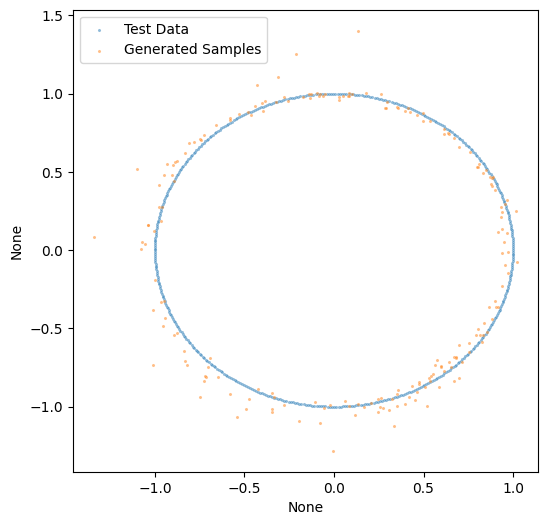

In [9]:
noise = torch.randn([200, 2]).to(device)
samples = edm_sampler(edm_model, noise, rho=7, sigma_min=2e-2, sigma_max=10.0, num_steps=100).detach()

# denormalize the samples
samples = samples * torch.std(data) / 0.5

plt.figure(figsize=(6, 6))
sns.scatterplot(x=viz_data[:, 0], y=viz_data[:, 1], s=5, alpha=0.5, label='Test Data')
sns.scatterplot(x=samples[:, 0].cpu(), y=samples[:, 1].cpu(), s=5, alpha=0.5, label='Generated Samples')
plt.legend()
plt.show()